# **Load Packages**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##**Load dataset**

In [ ]:
df=pd.read_csv('spam_detection_dataset.csv')
df

,num_links,num_words,has_offer,sender_score,all_caps,is_spam
0,3,98,1,0.718607,0,0
1,0,170,0,0.698901,1,0
2,0,38,0,0.620466,0,0
3,0,116,0,0.701755,0,0
4,3,89,1,0.583621,1,1
...,...,...,...,...,...,...
19995,1,22,1,0.614551,0,0
19996,3,154,0,1.000000,1,1
19997,4,109,0,0.935848,1,0
19998,2,197,0,0.481772,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   num_links     20000 non-null  int64  
 1   num_words     20000 non-null  int64  
 2   has_offer     20000 non-null  int64  
 3   sender_score  20000 non-null  float64
 4   all_caps      20000 non-null  int64  
 5   is_spam       20000 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 937.6 KB


In [ ]:
df.dtypes

,0
num_links,int64
num_words,int64
has_offer,int64
sender_score,float64
all_caps,int64
is_spam,int64


In [ ]:
# check null values
# Count the number of null values in each column
df.isnull().sum()

,0
num_links,0
num_words,0
has_offer,0
sender_score,0
all_caps,0
is_spam,0


In [ ]:
# check unique values in target column
# Count the unique values in the 'target' column
df['is_spam'].value_counts()

,count
is_spam,
0,18165
1,1835


##Data Preprocessing

In [ ]:
# Step 1: Handling Missing Values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
num_links       0
num_words       0
has_offer       0
sender_score    0
all_caps        0
is_spam         0
dtype: int64


In [ ]:
#step 2:Handling the duplicates
print("\nNumber of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 402


In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

In [ ]:
# After removing duplicates
df = df.reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (19527, 5)


In [ ]:
#checking for duplicates
print("\nNumber of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [ ]:
df.head()

,num_links,num_words,has_offer,sender_score,is_spam
0,3,98,1,0.718607,0
1,0,170,0,0.698901,0
2,0,38,0,0.620466,0
3,0,116,0,0.701755,0
4,3,89,1,0.583621,1


In [ ]:
# capitalzing the column names
df.columns=[col.capitalize() for col in df.columns]
df

,Num_links,Num_words,Has_offer,Sender_score,Is_spam
0,3,98,1,0.718607,0
1,0,170,0,0.698901,0
2,0,38,0,0.620466,0
3,0,116,0,0.701755,0
4,3,89,1,0.583621,1
...,...,...,...,...,...
19522,1,22,1,0.614551,0
19523,3,154,0,1.000000,1
19524,4,109,0,0.935848,0
19525,2,197,0,0.481772,0


In [ ]:
# check unique values in target column
# Count the unique values in the 'target' column
df['Is_spam'].value_counts()

,count
Is_spam,
0,17696
1,1831


# Divide data into X and y variables

In [ ]:
#divide data into X and Y variable
X = df.drop(columns=['Is_spam'])  # Features
y = df['Is_spam']  # Target variable

X.shape, y.shape  # Display the shape of X and y

((19527, 4), (19527,))

In [ ]:
X.head()

,Num_links,Num_words,Has_offer,Sender_score
0,3,98,1,0.718607
1,0,170,0,0.698901
2,0,38,0,0.620466
3,0,116,0,0.701755
4,3,89,1,0.583621


In [ ]:
y.head()

,Is_spam
0,0
1,0
2,0
3,0
4,1


# Split the data into train and test part

In [ ]:
from sklearn.model_selection import train_test_split
# Split the data into train and test part
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Display the shape of the training and testing sets
print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Training set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (15621, 4), (15621,)
Training set shape: (3906, 4), (3906,)


In [ ]:
# Handle the imbalanced dataset using oversampling (SMOTE)
from imblearn.over_sampling import SMOTE

# Define SMOTE
smote = SMOTE(random_state=42)
# Separate features (X) and target (y)
X = df.drop(columns=['Is_spam'])
y = df['Is_spam']

# Apply SMOTE
X_resampled, y_resampled = smote.fit_resample(X, y)

# Display the shapes
print(f"Original dataset shape: {X.shape}, {y.shape}")
print(f"Resampled dataset shape: {X_resampled.shape}, {y_resampled.shape}")


Original dataset shape: (19527, 4), (19527,)
Resampled dataset shape: (35392, 4), (35392,)


In [ ]:
y_resampled.value_counts()

,count
Is_spam,
0,17696
1,17696


In [ ]:
print(X_train.head())
print("--------------")
print(y_train.head())

       Num_links  Num_words  Has_offer  Sender_score
1602           2        144          0      0.695635
19057          0         54          0      0.682319
7132           3        117          0      0.656791
13552          0         22          0      0.678012
3058           3        157          0      0.839268
--------------
1602     0
19057    0
7132     0
13552    0
3058     0
Name: Is_spam, dtype: int64


In [ ]:
# Split the dataset into train test part
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_resampled,y_resampled,test_size=0.2,random_state=42)

# Train the model

In [ ]:
# Load the model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.metrics import accuracy_score,mean_absolute_error,mean_squared_error
%matplotlib inline

In [ ]:
# List of machine learning classification models
# (we will train and compare their performance on the dataset)
models = [
    LogisticRegression(),       # Logistic Regression (linear model, good baseline)
    DecisionTreeClassifier(),   # Decision Tree (rule-based splits, interpretable)
    RandomForestClassifier(),   # Random Forest (ensemble of decision trees, more robust)
    SVC(),                      # Support Vector Classifier (finds best hyperplane, works well on high-dimensional data)
    KNeighborsClassifier()      # K-Nearest Neighbors (instance-based, predicts based on nearest neighbors)
]


In [ ]:
# Loop through all models in the list
for i in range(len(models)):
    # Train the current model on the training dataset
    models[i].fit(X_train, y_train)

    # Use the trained model to predict on the test dataset
    y_pred = models[i].predict(X_test)

    # Calculate and print the accuracy of the current model
    print(f"{models[i]} : {accuracy_score(y_test, y_pred) * 100}")

LogisticRegression() : 79.16372368978669
DecisionTreeClassifier() : 86.2833733578189
RandomForestClassifier() : 87.69600226020624
SVC() : 77.31317982765927
KNeighborsClassifier() : 89.15101002966522


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate Mean Squared Error (MSE)
# -> squares the difference between predicted and actual values, penalizes larger errors more
mse = mean_squared_error(y_test, y_pred)

# Calculate Mean Absolute Error (MAE)
# -> takes the absolute difference between predicted and actual values, easier to interpret
mae = mean_absolute_error(y_test, y_pred)

# Print the error metrics
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 0.10848989970334794
Mean Absolute Error: 0.10848989970334794


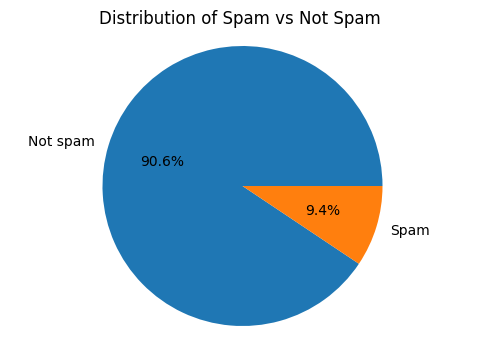

In [ ]:
spam_count = df['Is_spam'].value_counts()
labels = ['Not spam', 'Spam']
plt.figure(figsize=(6,4))
plt.pie(spam_count, labels=labels, autopct='%1.1f%%')
plt.title("Distribution of Spam vs Not Spam ")
plt.axis('equal')
plt.show()